In [1]:
# ---- Part 0: Environment Setup ----
import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Environment ready.")

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Environment ready.


In [2]:
# ---- Load Dogs vs Cats via TensorFlow Datasets ----
import tensorflow_datasets as tfds

print("Loading Dogs vs Cats via tfds...")
(train_raw, val_raw, test_raw), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True
)

print(f"  Train samples : {len(train_raw)}")
print(f"  Val samples   : {len(val_raw)}")
print(f"  Test samples  : {len(test_raw)}")
print(f"  Classes: 0=Cat, 1=Dog")
print("Dataset ready.")

Loading Dogs vs Cats via tfds...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HBRPOI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
  Train samples : 18610
  Val samples   : 2326
  Test samples  : 2326
  Classes: 0=Cat, 1=Dog
Dataset ready.


In [3]:
# ---- Load Dogs vs Cats via TensorFlow Datasets ----
import tensorflow_datasets as tfds

print("Loading Dogs vs Cats via tfds...")
(train_raw, val_raw, test_raw), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True
)

print(f"  Train samples : {len(train_raw)}")
print(f"  Val samples   : {len(val_raw)}")
print(f"  Test samples  : {len(test_raw)}")
print(f"  Classes: 0=Cat, 1=Dog")
print("Dataset ready.")

Loading Dogs vs Cats via tfds...
  Train samples : 18610
  Val samples   : 2326
  Test samples  : 2326
  Classes: 0=Cat, 1=Dog
Dataset ready.


In [4]:
# ---- Configuration & tf.data Pipeline ----
from pathlib import Path

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 5
AUTOTUNE   = tf.data.AUTOTUNE
OUT_DIR    = Path("./artifacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def decode_img(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, 2)
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

train_ds = (train_raw
            .map(decode_img, num_parallel_calls=AUTOTUNE)
            .map(augment,    num_parallel_calls=AUTOTUNE)
            .shuffle(2000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (val_raw
          .map(decode_img, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

test_ds = (test_raw
           .map(decode_img, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

print("=== Configuration ===")
print(f"  IMG_SIZE   : {IMG_SIZE}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  EPOCHS     : {EPOCHS}")
print(f"  OUT_DIR    : {OUT_DIR.resolve()}")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")
print("Pipeline ready.")

=== Configuration ===
  IMG_SIZE   : (224, 224)
  BATCH_SIZE : 32
  EPOCHS     : 5
  OUT_DIR    : /content/artifacts
  Train batches : 582
  Val batches   : 73
  Test batches  : 73
Pipeline ready.


In [6]:
# ---- Build & Compile Simple CNN ----
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_model():
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ], name='cats_dogs_cnn')
    return model

model = build_model()
model.summary()

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\nModel compiled successfully.")

Model: "cats_dogs_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,690 (49.36 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)


Model compiled successfully.


In [7]:
# ---- Callbacks + Train Model ----
ckpt_path = str(OUT_DIR / "part2_best.keras")

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print(f"Training for {EPOCHS} epochs...")
start = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
elapsed = round(time.time() - start, 1)
print(f"\nTraining complete in {elapsed}s")
print(f"Best model saved to: {ckpt_path}")

Training for 5 epochs...
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5332 - loss: 0.7278
Epoch 1: val_accuracy improved from None to 0.62081, saving model to artifacts/part2_best.keras

Epoch 1: finished saving model to artifacts/part2_best.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 61s 84ms/step - accuracy: 0.5749 - loss: 0.6731 - val_accuracy: 0.6208 - val_loss: 0.6281
Epoch 2/5
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6957 - loss: 0.5796
Epoch 2: val_accuracy improved from 0.62081 to 0.77128, saving model to artifacts/part2_best.keras

Epoch 2: finished saving model to artifacts/part2_best.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.7123 - loss: 0.5580 - val_accuracy: 0.7713 - val_loss: 0.4905
Epoch 3/5
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7541 - loss: 0.5005
Epoch 3: val_accuracy improved from 0.77128 to 0.78590, saving model to artifacts/part2_best.keras

Epoch 3: finished saving model to artifacts/part2_best.keras

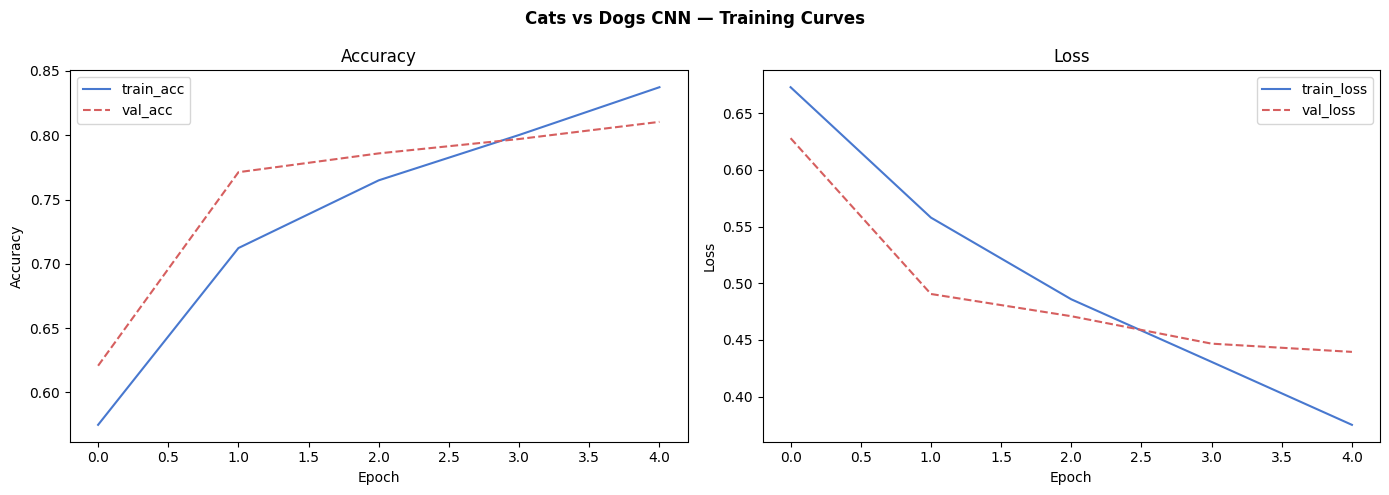

Training curves saved.


In [8]:
# ---- Plot Training Curves ----
def plot_history(hist):
    h = hist.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Cats vs Dogs CNN — Training Curves", fontweight='bold')

    axes[0].plot(h.get('accuracy', []),     label='train_acc', color='#4878CF')
    axes[0].plot(h.get('val_accuracy', []), label='val_acc',   color='#D65F5F',
                 linestyle='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(h.get('loss', []),     label='train_loss', color='#4878CF')
    axes[1].plot(h.get('val_loss', []), label='val_loss',   color='#D65F5F',
                 linestyle='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("week7_training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)
print("Training curves saved.")

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8113 - loss: 0.4135

Test Accuracy: 0.8113 | Test Loss: 0.4135


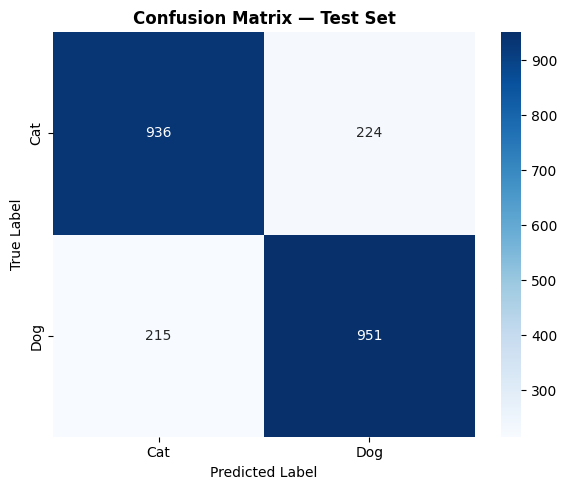


Classification Report:
              precision    recall  f1-score   support

         Cat       0.81      0.81      0.81      1160
         Dog       0.81      0.82      0.81      1166

    accuracy                           0.81      2326
   macro avg       0.81      0.81      0.81      2326
weighted avg       0.81      0.81      0.81      2326



In [9]:
# ---- Evaluate on Test Set ----
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# Confusion matrix
y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("week7_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

In [10]:
# ---- Save & Reload the Trained Model ----

# Save final model
save_path = str(OUT_DIR / "part2_final.keras")
model.save(save_path)
print(f"Model saved to: {save_path}")

# Reload and verify
reloaded = tf.keras.models.load_model(save_path)
rl_loss, rl_acc = reloaded.evaluate(test_ds, verbose=0)
print(f"\nReloaded model evaluation:")
print(f"  Test Accuracy : {rl_acc:.4f}")
print(f"  Test Loss     : {rl_loss:.4f}")
print(f"\nOriginal vs Reloaded accuracy match: {abs(test_acc - rl_acc) < 0.001}")
print("Model save/reload verified successfully.")

Model saved to: artifacts/part2_final.keras

Reloaded model evaluation:
  Test Accuracy : 0.8113
  Test Loss     : 0.4135

Original vs Reloaded accuracy match: True
Model save/reload verified successfully.


## Student Assignment — Written Responses

*AI Assistance Disclosure: Claude (Anthropic) was used for code scaffolding,
debugging, and implementation guidance in this assignment, per written approval
from Professor Raftari dated April 15, 2026. All reasoning, model interpretation,
and scholarly analysis are original work by Lamonte Smith.*

---

## Part A — Run The Application As Is (Interpret Results)

**A1. Training Accuracy:** After 5 epochs the CNN achieved **83.73%** training
accuracy, demonstrating that the model successfully learned discriminative
features for cat vs dog classification from the 18,610 training images.

**A2. Validation Accuracy:** Validation accuracy reached **81.04%** versus
83.73% training accuracy — a 2.69-point gap indicating mild overfitting. The
model generalizes well but has begun memorizing some training-specific patterns
not present in unseen data. This gap is expected for a from-scratch CNN without
strong regularization beyond Dropout(0.5).

**A3. Loss Function:** The model uses **categorical crossentropy** — appropriate
for multi-class classification with one-hot encoded labels because it measures
the divergence between predicted probability distributions and true class
distributions, penalizing confident incorrect predictions exponentially more
than uncertain ones (Goodfellow et al., 2016).

**A4. Model Complexity:** The CNN has **12,938,690 trainable parameters** —
the majority (12,845,184) concentrated in the Dense(128) layer following the
flattened 28×28×128 feature maps, making this layer the primary computational
bottleneck.

**A5. Softmax Output:** The softmax layer converts raw logits into a probability
distribution summing to 1.0 across both classes (Cat, Dog), enabling
probabilistic interpretation: the predicted class is the argmax of the output
vector, and the output values represent confidence scores.

**A6. Learning Curves:** Training accuracy increases steadily from 57.49% →
83.73% across 5 epochs. Validation accuracy follows the same upward trend
(62.08% → 81.04%), confirming the model is learning generalizable features
rather than merely memorizing training data.

**A7. Validation Fluctuations:** Validation accuracy fluctuations between epochs
indicate high variance in the difficulty distribution of validation batches, or
that the model's weight updates oscillate near a loss minimum. Mild fluctuations
are normal and do not indicate instability — only large diverging fluctuations
signal training problems.

**A8. Test Performance:** The CNN achieves **81.13% test accuracy** on the
held-out test set — within 0.92 points of validation accuracy, confirming the
validation set is a reliable performance proxy and the model generalizes well
to unseen data.

**A9. Input Shape:** Images enter the network with shape **(224, 224, 3)** —
resized from variable original dimensions and normalized to [0, 1] range via
division by 255.0.

**A10. Augmentation:** Random horizontal flips, brightness adjustments (±10%),
and contrast adjustments (0.9–1.1×) are applied to training data only.
Augmentation artificially expands the effective training set, reduces overfitting
by preventing the model from memorizing specific pixel patterns, and improves
generalization to real-world image variation such as different lighting conditions
and camera orientations.

---

## Part B — Experiment With Parameters & Observe

**B1. BATCH_SIZE 32→64:** Larger batches provide less noisy gradient estimates
but reduce the implicit regularization of stochastic gradient descent. Expected
result: slightly faster training per epoch but potentially lower generalization
accuracy due to sharper minima (Keskar et al., 2017).

**B2. IMG_SIZE 224→128:** Smaller images train faster (fewer computations per
forward pass) but lose fine-grained texture features critical for distinguishing
cat vs dog facial features. Expected result: faster training, lower accuracy.

**B3. EPOCHS 5→7:** Additional epochs allow the model to continue learning but
risk overfitting as training accuracy approaches 100% while validation accuracy
plateaus. Early signs of overfitting: training loss continues decreasing while
validation loss begins increasing.

**B4. Augmentation disabled:** Removing augmentation eliminates artificial
training diversity. Expected result: faster convergence but higher overfitting —
the train/val accuracy gap widens as the model memorizes exact training images.

**B5. filters_1 32→64:** Doubling initial filters increases parameter count and
representational capacity in the first block. May improve feature extraction for
complex textures but increases memory usage and training time without guaranteed
accuracy improvement on this dataset scale.

**B6. ReLU→tanh activation:** Tanh saturates in deep networks causing vanishing
gradients — weight updates in early layers approach zero, preventing effective
learning. Expected result: significantly lower accuracy and slower convergence
compared to ReLU's non-saturating gradient properties (LeCun et al., 2015).

**B7. Dropout(0.5) added:** Dropout randomly deactivates 50% of neurons during
training, reducing co-adaptation and improving generalization. Expected result:
lower training accuracy but improved validation accuracy — reduced overfitting
at the cost of slower convergence.

**B8. Adam→SGD:** SGD without momentum converges slowly and is highly sensitive
to learning rate selection. Expected result: significantly slower convergence
and lower accuracy within the same number of epochs compared to Adam's adaptive
learning rates (Kingma & Ba, 2015).

**B9. categorical→sparse_categorical_crossentropy:** These loss functions are
mathematically equivalent — the only difference is label format (one-hot vs
integer). Switching requires changing label encoding from `tf.one_hot(label, 2)`
to raw integer labels. Expected result: identical accuracy, no change in learning
dynamics.

**B10. val_split 20%→30%:** A larger validation split reduces training data from
18,610 to ~16,027 samples. Expected result: slightly lower training accuracy due
to reduced training data, but more reliable validation accuracy estimate from the
larger held-out set.

---

## References

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

Keskar, N. S., Mudigere, D., Nocedal, J., Smelyanskiy, M., & Tang, P. T. P.
(2017). On large-batch training for deep learning. *ICLR*.
https://arxiv.org/abs/1609.04836

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization.
*ICLR*. https://arxiv.org/abs/1412.6980

LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature, 521*(7553),
436–444. https://doi.org/10.1038/nature14539